In [6]:
# ---- Style
import matplotlib.pyplot as plt

PALETTE = ["#3A86FF", "#8338EC", "#FFBE0B", "#FB5607", "#FF006E", "#737373", "#264653"]

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
})

import os

import torch
from torch import nn
from torch import Tensor
import numpy as np
import torch.nn.functional as F
import yaml

from train import TrainConfig, load_module


# ---- Load Model & Dataloader
def load_model_dataloader(ckpt: str = "./checkpoints/1000_tuned_hrm_new/epoch_19.pt", data_split: str = "test_hard"):
    # Load config
    with open(os.path.join(os.path.dirname(ckpt), "model_config.json"), "r") as f:
        config_dict = yaml.safe_load(f)
    config = TrainConfig(**config_dict)

    # Initialize Dataloader
    create_dataloader = load_module(f"dataset.{config.data.name}@create_dataloader")
    
    # Load evaluation dataset
    eval_loader, metadata = create_dataloader(
        data_split, config.local_batch_size, rank=0, world_size=1, **config.data.__pydantic_extra__  # pyright: ignore[reportCallIssue]
    )

    # Initialize Model
    model_cls = load_module(f"arch.{config.arch.name}")
    with torch.device("cuda"):
        model = model_cls(config.arch.__pydantic_extra__ | metadata)
        # Load Checkpoint
        state_dict = torch.load(ckpt, map_location="cuda", weights_only=True)
        model.load_state_dict(state_dict, assign=True)
        model: nn.Module = torch.compile(model, dynamic=False, fullgraph=True)  # pyright: ignore[reportAssignmentType]

        model.eval()

    return model, eval_loader

model, eval_loader = load_model_dataloader()

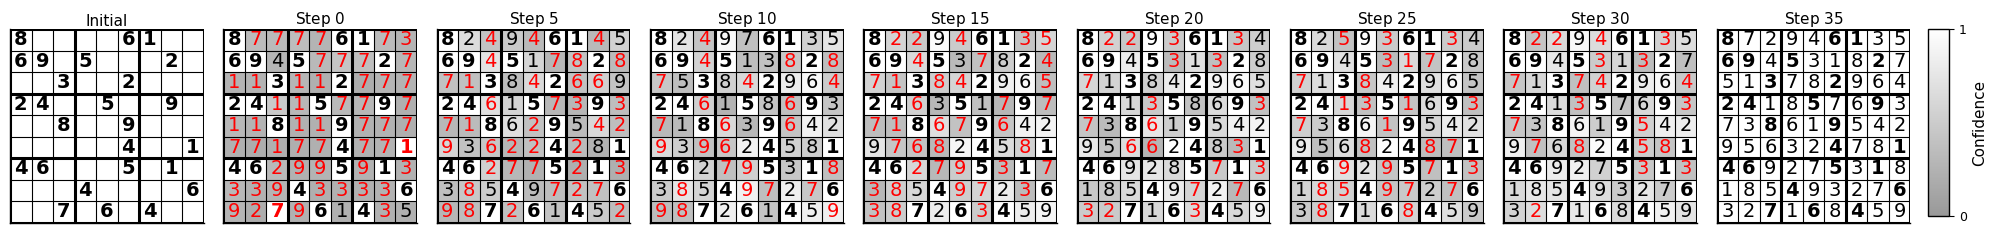

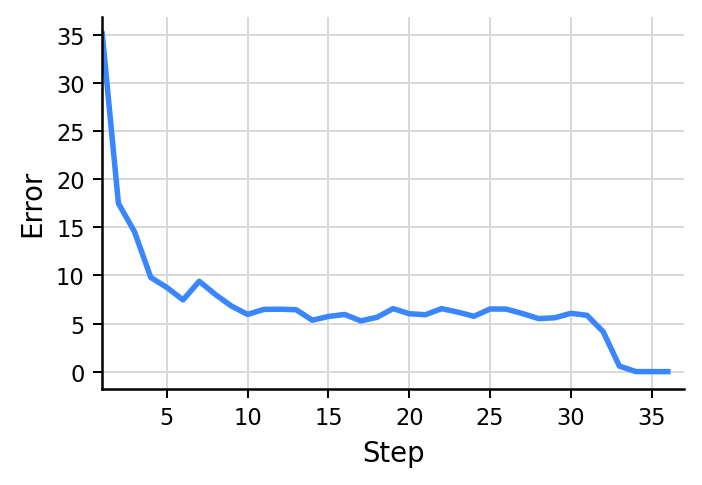

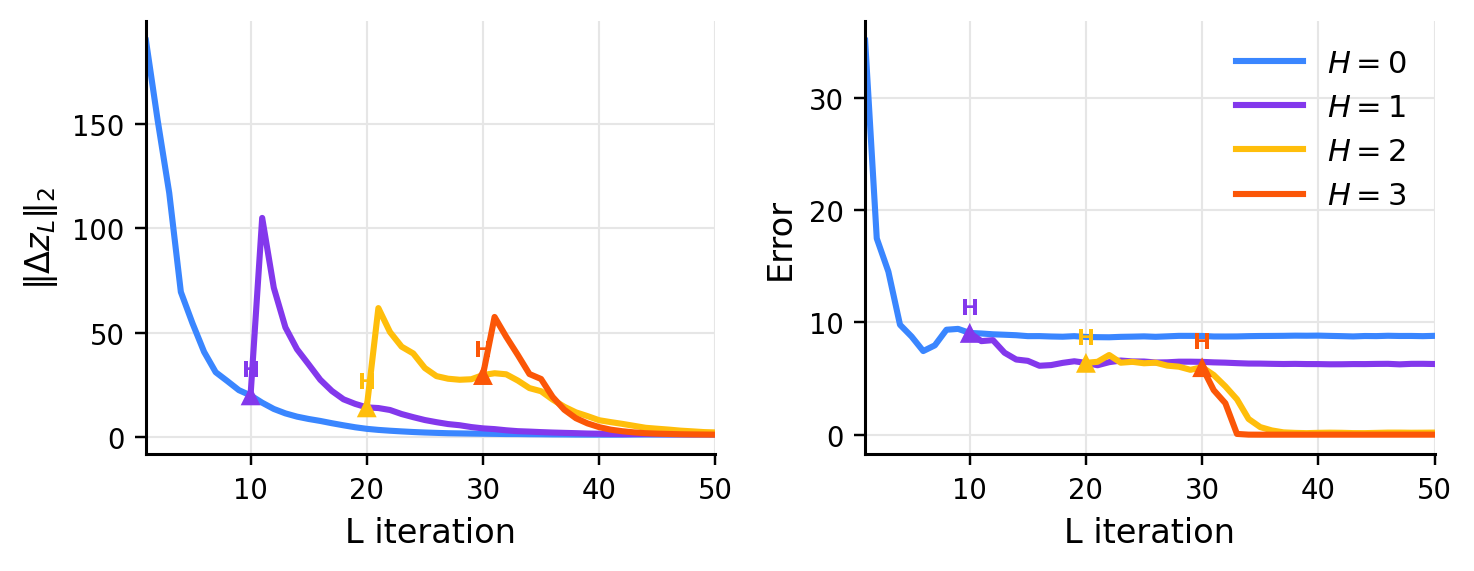

In [2]:
# --- Solution Trajectory
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable


def plot_sudoku_rollout(givens, probs, max_plots=8, figsize_per_board=2.2):
    """
    Visualize Sudoku predictions over time.

    Args:
        givens: (9, 9) int array, 0 means empty, 1..9 are givens
        probs:  (T, 9, 9, 9) float array in [0, 1]
        max_plots: maximum number of timestep plots to show (not counting "Initial")
                   Uses uniform subsampling and always includes the last step.
    """
    givens = np.asarray(givens)
    probs = np.asarray(probs)
    T = probs.shape[0]

    assert givens.shape == (9, 9)
    assert probs.ndim == 4 and probs.shape[1:] == (9, 9, 9)

    # Choose which timesteps to show
    if max_plots is None or max_plots >= T:
        steps = list(range(T))
    else:
        stride = int(np.ceil(T / max_plots))
        steps = list(range((T - 1) % stride, T, stride))

    # White at 1.0, gray at 0.0
    cmap = LinearSegmentedColormap.from_list("conf", ["#999999", "#ffffff"])
    norm = Normalize(vmin=0.0, vmax=1.0)

    n_boards = 1 + len(steps)  # initial + sampled timesteps
    fig, axes = plt.subplots(
        1, n_boards,
        figsize=(figsize_per_board * n_boards + 0.8, figsize_per_board),
        gridspec_kw={"wspace": 0.02}
    )
    if n_boards == 1:
        axes = [axes]

    def conflict_mask(board):
        bad = np.zeros((9, 9), dtype=bool)

        for r in range(9):
            for d in range(1, 10):
                cols = np.where(board[r] == d)[0]
                if len(cols) > 1:
                    bad[r, cols] = True

        for c in range(9):
            for d in range(1, 10):
                rows = np.where(board[:, c] == d)[0]
                if len(rows) > 1:
                    bad[rows, c] = True

        for br in range(3):
            for bc in range(3):
                rs = slice(3 * br, 3 * br + 3)
                cs = slice(3 * bc, 3 * bc + 3)
                box = board[rs, cs]
                for d in range(1, 10):
                    rr, cc = np.where(box == d)
                    if len(rr) > 1:
                        bad[3 * br + rr, 3 * bc + cc] = True

        return bad & (board != 0)

    def draw_grid(ax, board, conf=None, title=""):
        ax.set_xlim(0, 9)
        ax.set_ylim(9, 0)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title, fontsize=11, pad=2)

        bad = conflict_mask(board)

        for r in range(9):
            for c in range(9):
                val = 1.0 if conf is None else float(conf[r, c])
                ax.add_patch(Rectangle((c, r), 1, 1,
                                       facecolor=cmap(norm(val)),
                                       edgecolor="none"))

                d = int(board[r, c])
                if d != 0:
                    is_given = givens[r, c] != 0
                    ax.text(
                        c + 0.5, r + 0.5, str(d),
                        ha="center", va="center",
                        fontsize=14,
                        fontweight="bold" if is_given else "normal",
                        color="red" if bad[r, c] else "black"
                    )

        for k in range(10):
            lw = 2.2 if k % 3 == 0 else 0.8
            ax.plot([0, 9], [k, k], color="black", lw=lw)
            ax.plot([k, k], [0, 9], color="black", lw=lw)

    # Initial board
    draw_grid(axes[0], givens, conf=np.ones((9, 9)), title="Initial")

    # Sampled timesteps
    for i, t in enumerate(steps, start=1):
        pred = probs[t].argmax(axis=-1) + 1
        conf = probs[t].max(axis=-1)

        board = pred.copy()
        board[givens != 0] = givens[givens != 0]
        conf[givens != 0] = 1.0

        draw_grid(axes[i], board, conf=conf, title=fr"Step ${t}$")

    # Reserve space on the right for the colorbar, then add a dedicated axis there
    fig.subplots_adjust(left=0.01, right=0.94, top=0.90, bottom=0.02, wspace=0.02)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    cax = fig.add_axes([0.945, 0.05, 0.01, 0.85])  # [left, bottom, width, height]
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Confidence")
    cbar.set_ticks([0.0, 1.0])

    return fig, axes

def sudoku_loss(x: torch.Tensor) -> torch.Tensor:
    # 1. Cell constraint: sum across values (dim=-1) must be 1
    # After summing over values, sum over the remaining 2 spatial dims (-2, -1)
    cell_loss = (x.sum(dim=-1) - 1).relu().sum(dim=(-2, -1))
    
    # 2. Row constraint: sum across columns (dim=-2) must be 1
    row_loss = (x.sum(dim=-2) - 1).relu().sum(dim=(-2, -1))
    
    # 3. Column constraint: sum across rows (dim=-3) must be 1
    col_loss = (x.sum(dim=-3) - 1).relu().sum(dim=(-2, -1))
    
    # 4. Block constraint: sum across 3x3 subgrids must be 1
    # *x.shape[:-3] unpacks any batch dimensions dynamically
    # Reshapes to: (..., block_row=3, cell_row=3, block_col=3, cell_col=3, value=9)
    block_reshaped = x.view(*x.shape[:-3], 3, 3, 3, 3, 9)
    
    # Sum across cell_row (dim=-4) and cell_col (dim=-2)
    block_sums = block_reshaped.sum(dim=(-4, -2))
    
    # Sum the loss over block_row, block_col, and value (last 3 dims)
    block_loss = (block_sums - 1).relu().sum(dim=(-3, -2, -1))
    
    return cell_loss + row_loss + col_loss + block_loss

@torch.inference_mode()
def plot_traj_related(model, H_cycles: int = 6, convergence_H_cycles: int = 4, convergence_H_pad: int = 1, convergence_L_cycles: int = 10, puzzle="800006100690500020003002000240050090008009000000004001460005010000400006007060400", solution="872946135694531827513782964241857693738619542956324781469275318185493276327168459"):
    # Convert
    puzzle = np.frombuffer(puzzle.encode(), np.uint8).astype(np.int32) - ord("0")
    solution = np.frombuffer(solution.encode(), np.uint8).astype(np.int32) - ord("0")

    # --- Solve
    x = torch.from_numpy(np.pad(puzzle, (1, 0))).cuda()
    y = torch.from_numpy(solution).to(torch.long).cuda() - 1
    x = model.embed(x)
    
    carry = model.initial_carry
    z_H, z_L = carry["z_H"].expand_as(x), carry["z_L"].expand_as(x)

    pred = []
    losses = []
    for _i in range(H_cycles * model.L_cycles):
        z_L = model.L_level(z_L + z_H + x)
        logits = model.lm_head(model.H_level(z_H + z_L))[..., 1:, 1:].to(torch.float32)
        probs = logits.softmax(dim=-1)
        # Log states to CPU to save vram
        pred.append(probs.cpu().numpy())
        losses.append(sudoku_loss(probs.view(9, 9, 9)).item())

        # # Halt
        # if ((logits.argmax(dim=-1) + 1).cpu().numpy() == solution).all():
        #     break
        
        # H
        if (_i + 1) % model.L_cycles == 0:
            z_H = model.H_level(z_H + z_L)

    pred = np.stack(pred, axis=0)

    # --- Solve with virtual L
    carry = model.initial_carry
    z_H, z_L = carry["z_H"].expand_as(x), carry["z_L"].expand_as(x)

    convergence_losses = {}
    convergence_deltas = {}
    last_L = z_L
    for _i in range(convergence_H_cycles):
        convergence_losses[_i], convergence_deltas[_i] = [], []
        for _k in range(convergence_L_cycles):
            z_L = model.L_level(z_L + z_H + x)
            logits = model.lm_head(model.H_level(z_H + z_L))[..., 1:, 1:].to(torch.float32)
            probs = logits.softmax(dim=-1)
            # Log states to CPU to save vram
            convergence_losses[_i].append(sudoku_loss(probs.view(9, 9, 9)).item())
            convergence_deltas[_i].append(torch.linalg.vector_norm(last_L - z_L).item())
            last_L = z_L
        
        # Extend the L-cycles
        e_z_L = z_L
        e_last_L = last_L
        for _k in range((convergence_H_cycles - _i - 1 + convergence_H_pad) * convergence_L_cycles):
            e_z_L = model.L_level(e_z_L + z_H + x)
            logits = model.lm_head(model.H_level(z_H + e_z_L))[..., 1:, 1:].to(torch.float32)
            probs = logits.softmax(dim=-1)
            # Log states to CPU to save vram
            convergence_losses[_i].append(sudoku_loss(probs.view(9, 9, 9)).item())
            convergence_deltas[_i].append(torch.linalg.vector_norm(e_last_L - e_z_L).item())
            e_last_L = e_z_L

        # H
        z_H = model.H_level(z_H + z_L)

    # --- Plot Puzzle decoded state
    fig, axes = plot_sudoku_rollout(puzzle.reshape(9, 9), pred.reshape(-1, 9, 9, 9))
    fig.show()

    # --- Cross-entropy loss over steps
    fig, ax = plt.subplots(figsize=(4.0, 2.8), dpi=180)
    steps = np.arange(1, len(losses) + 1)

    ax.plot(steps, losses, lw=2.2, color=PALETTE[0])
    ax.set_xlabel("Step")
    ax.set_ylabel("Error")
    ax.set_xlim(1, len(losses) + 1)
    ax.grid(True, color="#D9D9D9", lw=0.8)
    ax.set_axisbelow(True)
    fig.tight_layout()
    fig.show()

    # --- delta and loss plots for convergence analysis
    total_L = len(convergence_deltas[0])
    fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.7), dpi=220, sharex=True)

    for i in range(convergence_H_cycles):
        color = PALETTE[i % len(PALETTE)]

        y_delta = np.asarray(convergence_deltas[i], dtype=float)
        y_loss = np.asarray(convergence_losses[i], dtype=float)
        n = len(y_loss)
        x = np.arange(total_L - n + 1, total_L + 1)

        # prepend the final point from the previous H cycle to show continuity
        if i > 0:
            y_delta = np.r_[convergence_deltas[i - 1][convergence_L_cycles - 1], y_delta]
            y_loss = np.r_[convergence_losses[i - 1][convergence_L_cycles - 1], y_loss]
            x = np.r_[x[0] - 1, x]

        axes[0].plot(x, y_delta, lw=2.0, color=color, label=fr"$H={i}$")
        axes[1].plot(x, y_loss, lw=2.0, color=color, label=fr"$H={i}$")

        if i > 0:
            fork_x = x[0]
            fork_delta = y_delta[0]
            fork_loss = y_loss[0]

            for ax, y0 in zip(axes, [fork_delta, fork_loss]):
                ax.scatter(
                    [fork_x], [y0], marker="^", s=42, color=color, edgecolor="none",
                    zorder=4, clip_on=False
                )
                ax.annotate(
                    "H", (fork_x, y0), xytext=(0, 5), textcoords="offset points",
                    ha="center", va="bottom", fontsize=7, color=color, fontweight="bold"
                )

    axes[0].set_ylabel(r"$\|\Delta z_L\|_2$")
    axes[1].set_ylabel("Error")
    for ax in axes:
        ax.set_xlabel("L iteration")
        ax.set_xlim(1, total_L)
        ax.grid(True, color="#E6E6E6", lw=0.7)
        ax.set_axisbelow(True)

    axes[1].legend(frameon=False, loc="best", handlelength=2.2)
    fig.tight_layout(w_pad=1.0)
    fig.show()

plot_traj_related(model)


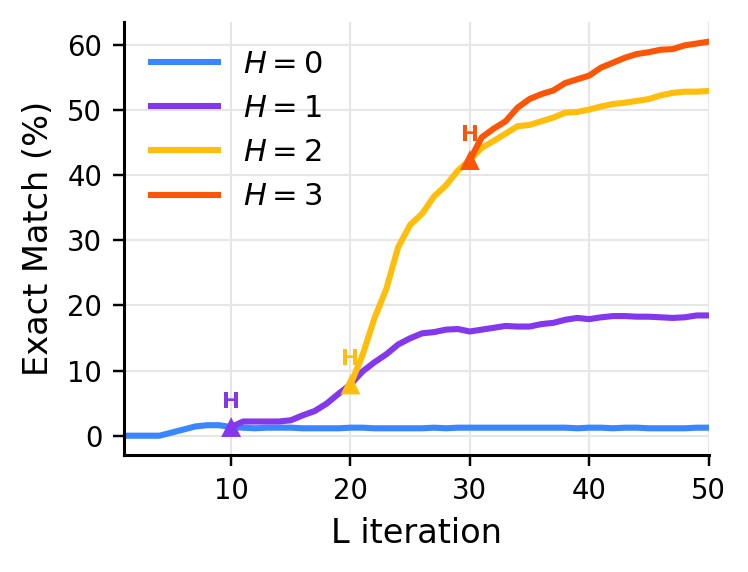

In [3]:

@torch.inference_mode()
def plot_all_stats(model, eval_loader, convergence_H_cycles: int = 4, convergence_H_pad: int = 1, convergence_L_cycles: int = 10):
    convergence_em = {_i: [0] * (convergence_H_cycles + convergence_H_pad - _i) * convergence_L_cycles for _i in range(convergence_H_cycles)}
    total = 0
    for x, y in eval_loader:
        x, y = x.cuda(), y.cuda()
        total += x.shape[0]
        # --- Solve with virtual L
        x = model.embed(x)
        carry = model.initial_carry
        z_H, z_L = carry["z_H"], carry["z_L"]

        for _i in range(convergence_H_cycles):
            for _k in range(convergence_L_cycles):
                z_L = model.L_level(z_L + z_H + x)
                preds = model.lm_head(model.H_level(z_H + z_L)).argmax(-1)

                convergence_em[_i][_k] += torch.sum((preds == y).all(dim=-1)).item()

            # Extend the L-cycles
            e_z_L = z_L
            for _k in range(convergence_L_cycles, (convergence_H_cycles + convergence_H_pad - _i) * convergence_L_cycles):
                e_z_L = model.L_level(e_z_L + z_H + x)
                preds = model.lm_head(model.H_level(z_H + e_z_L)).argmax(-1)

                convergence_em[_i][_k] += torch.sum((preds == y).all(dim=-1)).item()

            # H
            z_H = model.H_level(z_H + z_L)

        if total >= 1000:
            break

    convergence_em = {k: [x / total * 100 for x in arr] for k, arr in convergence_em.items()}
    
    # --- acc for convergence analysis
    total_L = len(convergence_em[0])
    fig, ax = plt.subplots(figsize=(3.5, 2.7), dpi=220)
    for i in range(convergence_H_cycles):
        color = PALETTE[i % len(PALETTE)]

        y_delta = np.asarray(convergence_em[i], dtype=float)
        n = len(y_delta)
        x = np.arange(total_L - n + 1, total_L + 1)

        # Prepend the final point from the previous H cycle to show continuity
        if i > 0:
            y_delta = np.r_[convergence_em[i - 1][convergence_L_cycles - 1], y_delta]
            x = np.r_[x[0] - 1, x]

        ax.plot(x, y_delta, lw=2.0, color=color, label=fr"$H={i}$")

        if i > 0:
            fork_x = x[0]
            fork_delta = y_delta[0]
            # Scatter and annotate for the single axis
            ax.scatter(
                [fork_x], [fork_delta], marker="^", s=42, color=color, edgecolor="none",
                zorder=4, clip_on=False
            )
            ax.annotate(
                "H", (fork_x, fork_delta), xytext=(0, 5), textcoords="offset points",
                ha="center", va="bottom", fontsize=7, color=color, fontweight="bold"
            )

    # Apply formatting to the single axis
    ax.set_ylabel("Exact Match (%)")
    ax.set_xlabel("L iteration")
    ax.set_xlim(1, total_L)
    ax.grid(True, color="#E6E6E6", lw=0.7)
    ax.set_axisbelow(True)

    ax.legend(frameon=False, loc="best", handlelength=2.2)
    fig.tight_layout()
    fig.show()

plot_all_stats(model, eval_loader)

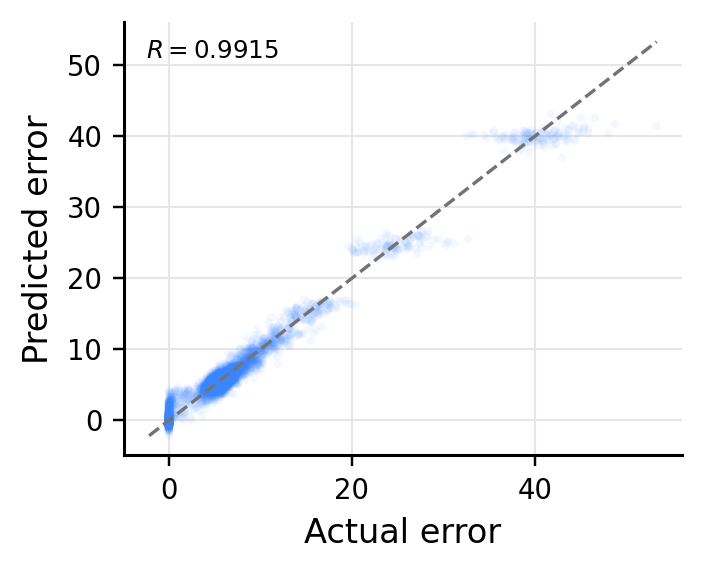

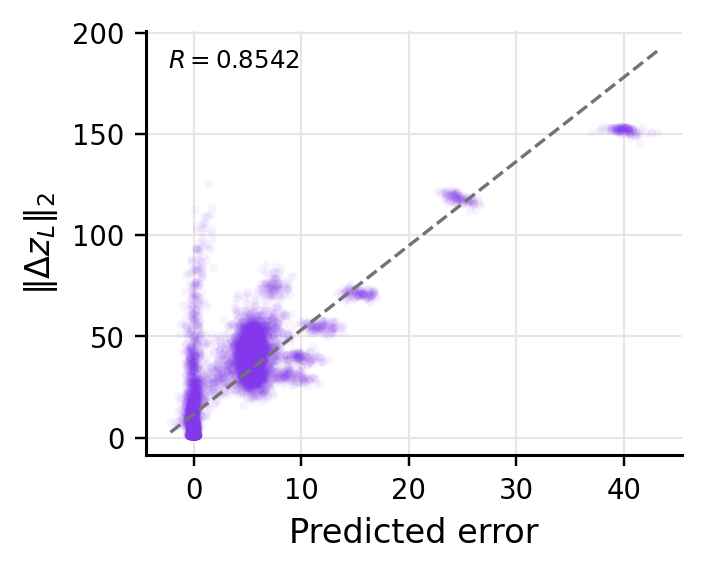

In [4]:

@torch.inference_mode()
def plot_corr(model, eval_loader, H_cycles: int = 16):
    states = []
    errors = []
    stepsizes = []

    total = 0
    for x, y in eval_loader:
        x, y = x.cuda(), y.cuda()
        total += x.shape[0]
        # --- Solve
        x = model.embed(x)
        carry = model.initial_carry
        z_H, z_L = carry["z_H"].expand_as(x), carry["z_L"].expand_as(x)

        for _i in range(H_cycles):
            for _k in range(model.L_cycles):
                z_L = model.L_level(z_L + z_H + x)
                logits = model.lm_head(model.H_level(z_H + z_L))
                # Collect trajectories
                states.append(torch.cat((z_L, z_H), dim=-1).mean(dim=-2))
                errors.append(sudoku_loss(logits[..., 1:, 1:].to(torch.float32).softmax(dim=-1).view(-1, 9, 9, 9)))
                stepsizes.append(torch.linalg.vector_norm(z_L - model.L_level(z_L + z_H + x), dim=(-1, -2), dtype=torch.float32))

            # H
            z_H = model.H_level(z_H + z_L)

        if total >= 1000:
            break

    states = torch.cat(states, dim=0)
    errors = torch.cat(errors, dim=0)
    stepsizes = torch.cat(stepsizes, dim=0)

    # --- GPU linear regression: state -> actual error
    X_aug = F.pad(states, (0, 1), value=1).to(torch.float32)  # Pad "bias"
    beta = torch.linalg.lstsq(X_aug, errors.unsqueeze(-1)).solution
    y_hat = (X_aug @ beta).squeeze(1)
    r_state = torch.corrcoef(torch.stack([errors, y_hat]))[0, 1].item()

    # --- plot state-regressed error
    n_plot = min(12000, errors.numel())
    idx = torch.randperm(errors.numel(), device=errors.device)[:n_plot]
    err_p = errors[idx].detach().cpu().numpy()
    hat_p = y_hat[idx].detach().cpu().numpy()

    lo, hi = min(err_p.min(), hat_p.min()), max(err_p.max(), hat_p.max())
    fig, ax = plt.subplots(figsize=(3.3, 2.7), dpi=220)
    ax.scatter(err_p, hat_p, s=8, alpha=0.05, color=PALETTE[0], edgecolors="none")
    ax.plot([lo, hi], [lo, hi], lw=1.1, ls="--", color=PALETTE[5])
    ax.set_xlabel("Actual error")
    ax.set_ylabel("Predicted error")
    ax.text(0.04, 0.96, fr"$R={r_state:.4f}$", transform=ax.transAxes,
            ha="left", va="top", fontsize=8)
    ax.grid(True, color="#E6E6E6", lw=0.7)
    ax.set_axisbelow(True)
    fig.tight_layout()
    fig.show()

    # --- plot predicted error vs. stepsize
    step_p = stepsizes[idx].detach().cpu().numpy()
    r_step = np.corrcoef(hat_p, step_p)[0, 1]

    fig, ax = plt.subplots(figsize=(3.3, 2.7), dpi=220)
    ax.scatter(hat_p, step_p, s=8, alpha=0.05, color=PALETTE[1], edgecolors="none")
    m, b = np.polyfit(hat_p, step_p, 1)
    x_line = np.linspace(hat_p.min(), hat_p.max(), 200)

    ax.plot(x_line, m * x_line + b, lw=1.1, ls="--", color=PALETTE[5])
    ax.set_xlabel("Predicted error")
    ax.set_ylabel(r"$\|\Delta z_L\|_2$")
    ax.text(0.04, 0.96, fr"$R={r_step:.4f}$", transform=ax.transAxes,
    ha="left", va="top", fontsize=8)
    ax.grid(True, color="#E6E6E6", lw=0.7)
    ax.set_axisbelow(True)
    fig.tight_layout()
    fig.show()

plot_corr(model, eval_loader)

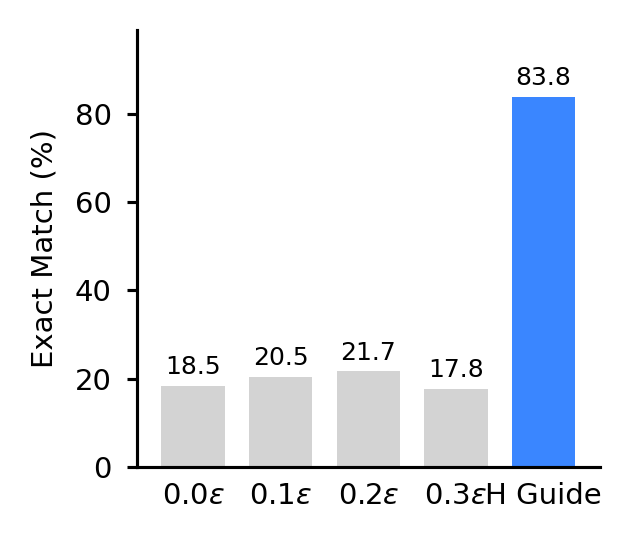

In [5]:
@torch.inference_mode()
def plot_random_kicks(model, eval_loader, H_warmup: int = 1, H_cycles: int = 32, noise_scales: list[float] = [0.0, 0.1, 0.2, 0.3]):
    em = {std: 0 for std in noise_scales}
    full_em = 0
    total = 0
    for x, y in eval_loader:
        x, y = x.cuda(), y.cuda()
        total += x.shape[0]
        # --- Solve with random kicks
        for std in noise_scales:
            e = model.embed(x)
            carry = model.initial_carry
            z_H, z_L = carry["z_H"], carry["z_L"]
            correct = False

            for _i in range(H_warmup):
                for _k in range(model.L_cycles):
                    z_L = model.L_level(z_L + z_H + e)
                z_H = model.H_level(z_H + z_L)

            for _i in range(H_cycles - H_warmup):
                perturb_H = z_H + std * torch.randn_like(e)
                for _k in range(model.L_cycles):
                    z_L = model.L_level(z_L + perturb_H + e)
            
                    preds = model.lm_head(model.H_level(z_H + z_L)).argmax(-1)
                    cur_correct = (preds == y).all(dim=-1)
                    if correct is None:
                        correct = cur_correct
                    correct |= cur_correct

            em[std] += torch.sum(correct).item()
        
        # --- Control: Full HRM Solve
        e = model.embed(x)
        carry = model.initial_carry
        z_H, z_L = carry["z_H"], carry["z_L"]
        for _i in range(H_cycles):
            for _k in range(model.L_cycles):
                z_L = model.L_level(z_L + z_H + e)
            z_H = model.H_level(z_H + z_L)
        
        preds = model.lm_head(model.H_level(z_H + z_L)).argmax(-1)
        full_em += ((preds == y).all(dim=-1)).sum().item()

        if total >= 1000:
            break

    em = {k: x / total * 100 for k, x in em.items()}

    # -- plot these as bar plots, name: $x \eps$, H Guide for full (last bar), Y: Exact Match (%). PALETTE[0] for H Guide, and light gray for others
    full = full_em / total * 100
    labels = [fr"${s:.1f}\epsilon$" for s in noise_scales] + ["H Guide"]
    vals = [em[s] for s in noise_scales] + [full]
    colors = ["#D3D3D3"] * len(noise_scales) + [PALETTE[0]]

    plt.rcParams["figure.dpi"] = 300
    fig, ax = plt.subplots(figsize=(2.2, 1.9))

    bars = ax.bar(range(len(vals)), vals, width=0.72, color=colors, edgecolor="none")
    ax.bar_label(bars, labels=[f"{v:.1f}" for v in vals], padding=1.5, fontsize=6)

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylabel("Exact Match (%)", fontsize=7)
    ax.set_ylim(0, max(vals) * 1.18 if max(vals) > 0 else 1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.75)
    ax.spines["bottom"].set_linewidth(0.75)
    ax.tick_params(axis="y", labelsize=7, width=0.75, length=2.5)
    ax.tick_params(axis="x", width=0.75, length=0)
    ax.margins(x=0.06)

    fig.tight_layout()
    plt.show()

plot_random_kicks(model, eval_loader)